# Laboratorio SECOP. Notebook del equipo
Data Analytics 2026-2. Semanas 1 y 2 de la actividad.

La asignación consiste en verificar una afirmación sobre la contratación pública colombiana con los datos reales del SECOP. Este notebook es la base de trabajo durante las dos semanas. Aquí se descargan los datos, se examina de qué están hechos y se construye la evidencia que terminará en el tablero y, una semana después, en el veredicto.

La ruta de trabajo:

    parámetros del caso > descarga congelada > perfilamiento
    > calidad y decisiones > evidencia E1, E2, E3 > tablero > semana 2

Cada celda está marcada en su primera línea. En las celdas PREPARADA se deben ajustar los parámetros según el detalle de la asignación, y luego ejecutar. Las celdas DEL EQUIPO son las suyas. Las celdas SEMANA 2 esperan a que reciba su objeción.

Cuatro condiciones de trabajo:

1. Toda cifra del tablero debe regenerarse ejecutando este notebook de principio a fin (Kernel, Restart and Run All). La reproducibilidad vale el 15 % de la calificación del laboratorio.
2. Los parámetros de la sección 1 los asignó el docente y no se modifican: cada equipo trabaja sobre un recorte distinto, a propósito.
3. El historial de commits del repositorio es la evidencia de su proceso de trabajo.
4. El uso de herramientas de IA se declara en la sección 8. Declarado no se penaliza; omitido, sí.


# 1. Parámetros del caso
Su caso es la combinación de expediente y recorte. Los valores de esta celda los asignó el docente; quedan escritos aquí para que cualquier persona, incluido su yo de la semana 2, pueda reproducir exactamente los mismos datos.


In [1]:
# PREPARADA. Parámetros asignados al Grupo 3

EXPEDIENTE   = "B"                       # expediente asignado
EQUIPO       = "Equipo 3"                # equipo asignado

# --- Filtros del recorte ---
VIGENCIA_DESDE = "2024-01-01"            # fecha de firma mínima (AAAA-MM-DD)
VIGENCIA_HASTA = "2025-12-31"            # fecha de firma máxima (AAAA-MM-DD)
DEPARTAMENTO   = "Distrito Capital de Bogotá"   # recorte territorial asignado
TIPO_CONTRATO  = None                    # la asignación no especifica tipo de contrato
LIMITE_FILAS   = None                    # None = descargar todo el recorte; no truncar a 200.000

RUTA_DATOS_CRUDOS = "data/raw/secop_recorte.csv"

print(f"Expediente {EXPEDIENTE}. {EQUIPO}")
print(f"Recorte: {DEPARTAMENTO or 'todo el país'}, {TIPO_CONTRATO or 'todos los tipos'}, {VIGENCIA_DESDE} a {VIGENCIA_HASTA}")


Expediente B. Equipo 3
Recorte: Distrito Capital de Bogotá, todos los tipos, 2024-01-01 a 2025-12-31


## 1.1. Criterio previo del equipo
La afirmación de su brief usa un término que los datos no traen como columna. En el expediente A, por ejemplo, ninguna columna del SECOP se llama "económicamente atractiva". Entonces, el equipo decide con qué variables medibles va a discutir ese término y qué resultado contaría a favor o en contra. Ese es el criterio previo, y se escribe aquí, antes de ejecutar la sección 2. La razón es simple, un criterio definido después de ver los resultados ya no es un criterio sino una justificación.

Un ejemplo del formato esperado, con el expediente A (los valores son ilustrativos; cada equipo fija y justifica los suyos):

- Dimensiones observables: valor mensual equivalente (VME) y duración del contrato.
- Evidencia a favor: que el VME mediano supere el ingreso mensual de referencia que el equipo tome para un profesional en inicio de carrera, en contratos con duración típica de seis meses o más.
- Evidencia en contra: que el VME mediano quede por debajo de esa referencia, o que la duración típica sea tan corta que el ingreso del año resulte bajo aun con un VME alto.

Ahora el de su equipo:

- Dimensiones observables que usaremos para discutir la afirmación: …
- Evidencia que consideraríamos a favor de la afirmación: …
- Evidencia que consideraríamos en contra: …


# 2. Adquisición del recorte
La primera ejecución descarga su subconjunto de datos desde la API de datos.gov.co (dataset SECOP II, Contratos Electrónicos, identificador `jbjy-vk9h`), por páginas, y lo congela como copia local en `data/raw/` junto con un registro de la consulta, la fecha y el número de filas. Desde ese momento el análisis corre siempre sobre la copia, sus cifras no dependerán de que la fuente cambie en el futuro.

Referencia de consulta: [pandas User Guide, IO](https://pandas.pydata.org/docs/user_guide/io.html)


In [3]:
# PREPARADA. descarga con paginación, conteo previo y respaldo local
import os
import json
import pandas as pd
import requests
from datetime import datetime, timezone

API_URL = "https://www.datos.gov.co/resource/jbjy-vk9h.json"
PAGINA = 50_000  # filas por llamada


def construir_where():
    """Arma el filtro SoQL a partir de los parámetros de la sección 1."""
    condiciones = [
        f"fecha_de_firma between '{VIGENCIA_DESDE}T00:00:00' and '{VIGENCIA_HASTA}T23:59:59'"
    ]
    if DEPARTAMENTO:
        condiciones.append(f"departamento = '{DEPARTAMENTO}'")
    if TIPO_CONTRATO:
        condiciones.append(f"tipo_de_contrato = '{TIPO_CONTRATO}'")
    return " AND ".join(condiciones)


def contar_recorte(where):
    """Consulta cuántos contratos cumplen exactamente el filtro."""
    params = {"$select": "count(*) as total", "$where": where}
    r = requests.get(API_URL, params=params, timeout=120)
    r.raise_for_status()
    datos = r.json()
    if not datos:
        return 0
    return int(datos[0]["total"])


def descargar_recorte(where, total):
    """Descarga el recorte completo, página por página."""
    marcos, offset = [], 0
    objetivo = total if LIMITE_FILAS is None else min(total, LIMITE_FILAS)

    while offset < objetivo:
        params = {
            "$where": where,
            "$limit": min(PAGINA, objetivo - offset),
            "$offset": offset,
            "$order": "fecha_de_firma, id_contrato",
        }
        r = requests.get(API_URL, params=params, timeout=120)
        r.raise_for_status()
        lote = r.json()
        if not lote:
            break
        marcos.append(pd.DataFrame(lote))
        print(f"  pagina con offset {offset:>7,}: {len(lote):,} filas")
        offset += len(lote)
        if len(lote) < params["$limit"]:
            break

    return pd.concat(marcos, ignore_index=True) if marcos else pd.DataFrame()


os.makedirs("data/raw", exist_ok=True)
where = construir_where()
usar_local = False
meta = None

# Reutiliza la copia local solo si corresponde al filtro actual.
if os.path.exists(RUTA_DATOS_CRUDOS) and os.path.exists("data/raw/metadata_extraccion.json"):
    with open("data/raw/metadata_extraccion.json", encoding="utf-8") as f:
        meta = json.load(f)
    usar_local = meta.get("consulta_where") == where

if usar_local:
    print(f"Usando la copia local del recorte: {RUTA_DATOS_CRUDOS}")
    print(f"  extraída el {meta['fecha_extraccion_utc']}, {meta['registros']:,} registros")
    df = pd.read_csv(RUTA_DATOS_CRUDOS, dtype=str)
else:
    print("Descargando desde datos.gov.co…")
    print("Contando primero los contratos que cumplen el filtro…")
    total = contar_recorte(where)
    print(f"  contratos que cumplen el filtro: {total:,}")
    if total == 0:
        raise ValueError(
            "El filtro no devolvió registros. Revise DEPARTAMENTO y las fechas antes de continuar."
        )
    if LIMITE_FILAS is not None and total > LIMITE_FILAS:
        print(f"  ADVERTENCIA: el recorte tiene {total:,} filas y LIMITE_FILAS={LIMITE_FILAS:,}; se descargará solo el límite.")
    df = descargar_recorte(where, total)
    df.to_csv(RUTA_DATOS_CRUDOS, index=False)
    with open("data/raw/metadata_extraccion.json", "w", encoding="utf-8") as f:
        json.dump({
            "dataset": "jbjy-vk9h (SECOP II - Contratos Electrónicos)",
            "consulta_where": where,
            "registros_consultados": total,
            "fecha_extraccion_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
            "registros": int(len(df)),
        }, f, ensure_ascii=False, indent=2)
    print(f"Guardado en {RUTA_DATOS_CRUDOS} (+ metadata_extraccion.json)")

print(f"\nRecorte cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")


Descargando desde datos.gov.co…
Contando primero los contratos que cumplen el filtro…
  contratos que cumplen el filtro: 567,075
  pagina con offset       0: 50,000 filas
  pagina con offset  50,000: 50,000 filas
  pagina con offset 100,000: 50,000 filas
  pagina con offset 150,000: 50,000 filas
  pagina con offset 200,000: 50,000 filas
  pagina con offset 250,000: 50,000 filas
  pagina con offset 300,000: 50,000 filas
  pagina con offset 350,000: 50,000 filas
  pagina con offset 400,000: 50,000 filas
  pagina con offset 450,000: 50,000 filas
  pagina con offset 500,000: 50,000 filas
  pagina con offset 550,000: 17,075 filas
Guardado en data/raw/secop_recorte.csv (+ metadata_extraccion.json)

Recorte cargado: 567,075 filas × 85 columnas


## 2.1. Verificación de columnas clave
Los nombres de columna de la API pueden cambiar entre versiones del dataset. Esta celda revisa el mapeo una sola vez; si algo difiere, se ajusta aquí con el profesor y el resto del notebook queda a salvo.


In [4]:
# PREPARADA. Mapeo de nombre lógico a columna real del recorte.
COL = {
    "valor":          "valor_del_contrato",
    "fecha_firma":    "fecha_de_firma",
    "fecha_inicio":   "fecha_de_inicio_del_contrato",
    "fecha_fin":      "fecha_de_fin_del_contrato",
    "entidad":        "nombre_entidad",
    "nit_proveedor":  "documento_proveedor",
    "proveedor":      "proveedor_adjudicado",
    "modalidad":      "modalidad_de_contratacion",
    "tipo":           "tipo_de_contrato",
    "id_contrato":    "id_contrato",
    "referencia":     "referencia_del_contrato",
    "objeto":         "descripcion_del_proceso",
}

faltan = {k: v for k, v in COL.items() if v not in df.columns}
if faltan:
    print("Advertencia: columnas del mapeo que no están en el recorte (ajustar COL con el docente):")
    for k, v in faltan.items():
        print(f"   {k:>14} -> '{v}'")
    print("\nColumnas disponibles en su recorte:")
    print(sorted(df.columns.tolist()))
else:
    print("Verificación correcta: todas las columnas clave están presentes.")

# Conversión de tipos mínimos (el valor llega como texto desde la API)
if COL["valor"] in df.columns:
    df[COL["valor"]] = pd.to_numeric(df[COL["valor"]], errors="coerce")
for k in ("fecha_firma", "fecha_inicio", "fecha_fin"):
    if COL[k] in df.columns:
        df[COL[k]] = pd.to_datetime(df[COL[k]], errors="coerce")

Verificación correcta: todas las columnas clave están presentes.


## 2.2. Primer contacto
Cinco preguntas antes de todo (diapositiva 3): cuántos contratos, qué tipos de datos, cuántas entidades y proveedores, qué periodo cubre de verdad, qué columnas están casi vacías. Ejecute y lea; la primera pista del expediente suele estar en esta salida.


In [5]:
# PREPARADA. primer contacto
print("Dimensiones:", df.shape)
print("\nPeriodo real de firma:", df[COL["fecha_firma"]].min(), "a", df[COL["fecha_firma"]].max())
print("Entidades distintas:  ", df[COL["entidad"]].nunique())
print("Proveedores (por NIT):", df[COL["nit_proveedor"]].nunique())
df.info()

Dimensiones: (567075, 85)

Periodo real de firma: 2024-01-02 00:00:00 a 2025-12-31 00:00:00
Entidades distintas:   393
Proveedores (por NIT): 252681
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 567075 entries, 0 to 567074
Data columns (total 85 columns):
 #   Column                                                            Non-Null Count   Dtype         
---  ------                                                            --------------   -----         
 0   nombre_entidad                                                    567075 non-null  object        
 1   nit_entidad                                                       567075 non-null  object        
 2   departamento                                                      567075 non-null  object        
 3   ciudad                                                            567075 non-null  object        
 4   localizaci_n                                                      567075 non-null  object        
 5   orden         

Su turno. Dos aspectos de la salida que no esperaban:

1. …
2. …


## 2.3. Clasificación de columnas (para diligenciar por el equipo)
Clasifiquen las columnas que usarán en las cuatro familias (diapositiva 4):

| Familia | Columnas de nuestro recorte |
|---|---|
| Numéricas | … |
| Categóricas | … |
| Fechas | … |
| Texto / identificadores | … |


# 3. Perfilamiento: describir es responder preguntas
Las funciones ya están escritas; el trabajo de su equipo es leer la salida y decidir qué significa para la afirmación. Centro, posición y dispersión responden preguntas distintas (diapositiva 5): cuál es el contrato típico, dónde cae uno frente a los demás, qué tan distintos son entre sí.

Referencias de consulta: [pandas, Working with missing data](https://pandas.pydata.org/docs/user_guide/missing_data.html) y [pandas, Descriptive statistics](https://pandas.pydata.org/docs/user_guide/basics.html#descriptive-statistics).


In [6]:
# PREPARADA. funciones de perfilamiento
import matplotlib.pyplot as plt
import numpy as np


def tabla_faltantes(df):
    """% de faltantes por columna, de mayor a menor."""
    t = (df.isna().mean() * 100).round(1).sort_values(ascending=False)
    return t[t > 0].rename("% faltante").to_frame()


def perfil_valor(df, col_valor):
    """Descriptivos clave de una columna numérica, en formato legible."""
    s = df[col_valor].dropna()
    filas = {
        "n (no nulos)": f"{s.size:,}",
        "en $0": f"{(s == 0).sum():,}",
        "media": f"${s.mean():,.0f}",
        "mediana (P50)": f"${s.median():,.0f}",
        "P25": f"${s.quantile(.25):,.0f}",
        "P75": f"${s.quantile(.75):,.0f}",
        "P95": f"${s.quantile(.95):,.0f}",
        "máximo": f"${s.max():,.0f}",
    }
    return pd.Series(filas).to_frame("valor")


def histograma_doble(df, col_valor, titulo):
    """Histograma en escala lineal y logarítmica, lado a lado (diapositiva 6)."""
    s = df[col_valor].dropna()
    s_pos = s[s > 0]
    fig, ejes = plt.subplots(1, 2, figsize=(12, 4))
    ejes[0].hist(s, bins=60, color="#1E2761")
    ejes[0].set_title(f"{titulo} — escala lineal")
    ejes[1].hist(np.log10(s_pos), bins=60, color="#E8A13D")
    ejes[1].set_title(f"{titulo} — log10 (solo > $0)")
    for e in ejes:
        e.set_ylabel("contratos")
    plt.tight_layout()
    plt.show()


def valor_mensual_equivalente(df, col_valor, col_inicio, col_fin, min_dias=30):
    """Valor mensual equivalente estimado: valor total / meses de duración.
    Solo se calcula para contratos con fechas válidas, duración >= min_dias y valor > 0.
    NO es un salario ni el flujo mensual efectivamente recibido: documente esta
    limitación si usa la medida en su tablero."""
    dias = (df[col_fin] - df[col_inicio]).dt.days
    valida = dias.ge(min_dias) & df[col_valor].gt(0)
    vme = df.loc[valida, col_valor] / (dias[valida] / 30.44)
    print(f"Contratos con VME calculable: {valida.sum():,} de {len(df):,}")
    return vme


def top_categorias(df, col, n=10):
    """Las n categorías más frecuentes con su proporción."""
    t = df[col].value_counts(dropna=False).head(n)
    return (
        t.to_frame("contratos")
         .assign(**{"% del recorte": (t / len(df) * 100).round(1)})
    )

print("Funciones disponibles: tabla_faltantes, perfil_valor, histograma_doble, valor_mensual_equivalente, top_categorias")

Funciones disponibles: tabla_faltantes, perfil_valor, histograma_doble, valor_mensual_equivalente, top_categorias


In [7]:
# PREPARADA. perfil de la variable clave del expediente
perfil_valor(df, COL["valor"])

,valor
n (no nulos),"567,075"
en $0,"5,501"
media,"$229,737,420"
mediana (P50),"$34,724,250"
P25,"$18,650,332"
P75,"$60,032,426"
P95,"$181,773,750"
máximo,"$4,205,027,751,839"


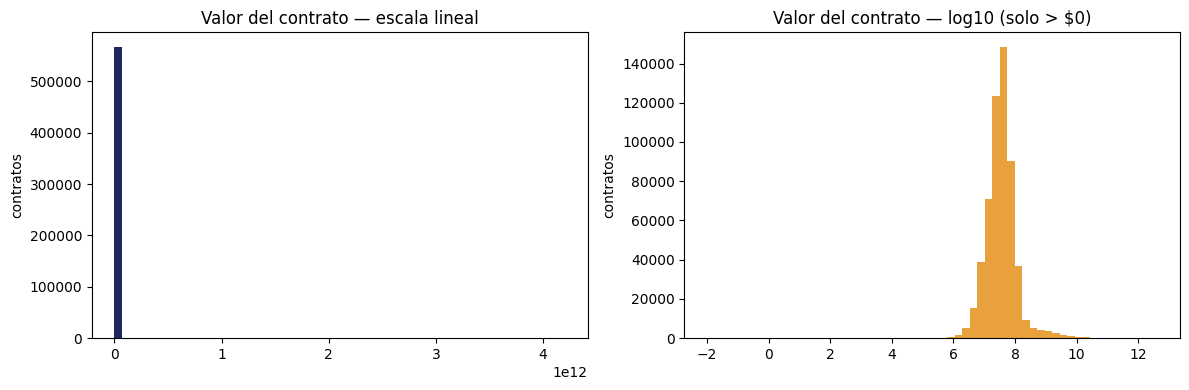

In [8]:
# PREPARADA. la forma de la distribución
histograma_doble(df, COL["valor"], "Valor del contrato")

In [9]:
# DEL EQUIPO. exploren lo que su expediente necesita.
# Su turno. Opciones de partida; use solo las que su expediente pide:
#   top_categorias(df, COL["modalidad"])
#   top_categorias(df, COL["entidad"], n=15)
#   df["duracion_dias"] = (df[COL["fecha_fin"]] - df[COL["fecha_inicio"]]).dt.days
#   perfil_valor(df, "duracion_dias")
#   df["vme"] = valor_mensual_equivalente(df, COL["valor"], COL["fecha_inicio"], COL["fecha_fin"])
#   perfil_valor(df.assign(vme=df["vme"]), "vme")   # expediente A: valor mensual equivalente


Lectura de la evidencia, en tres a cinco líneas describa. Si la media y la mediana cuentan historias distintas, cuál reportarán y por qué (diapositiva 10); y qué revela el histograma en escala logarítmica que la escala lineal esconde.

…


# 4. Calidad de datos: el faltante, el duplicado y el extremo
La cápsula 2 de la sesión presenta las tres familias de problemas; en esta sección usted las encuentra en sus propios datos. Ninguna se corrige en silencio: cada tratamiento queda escrito en la sección 4.4.


## 4.1. Faltantes (diapositiva 7)

In [10]:
# PREPARADA. ¿cuánto falta y dónde?
tabla_faltantes(df)

,% faltante
fecha_de_notificaci_n_de_prorrogaci_n,91.5
fecha_inicio_liquidacion,91.3
fecha_fin_liquidacion,91.3
ultima_actualizacion,31.7
fecha_de_inicio_del_contrato,0.3


In [11]:
# DEL EQUIPO. ¿el faltante tiene patrón?
# Ejemplo: ¿la fecha de fin vacía se concentra en contratos recientes o en cierto estado?
# df[df[COL["fecha_fin"]].isna()][COL["fecha_firma"]].dt.year.value_counts()


## 4.2. Duplicados e identidades (diapositiva 8)

In [12]:
# PREPARADA. filas vs. contratos, y NIT vs. razón social
print("Filas del recorte:                 ", f"{len(df):,}")
print("IDs de contrato distintos:         ", f"{df[COL['id_contrato']].nunique():,}")
print("Referencias de proceso distintas:  ", f"{df[COL['referencia']].nunique():,}")
print()
razones_por_nit = df.groupby(COL["nit_proveedor"])[COL["proveedor"]].nunique()
sospechosos = razones_por_nit[razones_por_nit > 1].sort_values(ascending=False)
print(f"NITs escritos con más de una razón social: {len(sospechosos):,}")
sospechosos.head(10)

Filas del recorte:                  567,075
IDs de contrato distintos:          567,075
Referencias de proceso distintas:   416,325

NITs escritos con más de una razón social: 177


,proveedor_adjudicado
documento_proveedor,
No Definido,1288
899999061,32
830073329,10
899999114,10
0,7
830005066,6
900000000,6
000000000,5
890399011,5


In [13]:
# DEL EQUIPO. definan su llave de deduplicación y aplíquenla.
# ¿Qué identifica un contrato único en SU recorte? Justifíquenlo en la decisión 1 de abajo.
# df_limpio = df.drop_duplicates(subset=[COL["id_contrato"]], keep="last")


## 4.3. Outliers (diapositiva 9)

In [14]:
# PREPARADA. los 5 contratos de mayor valor, con su objeto
cols_ver = [COL["valor"], COL["entidad"], COL["proveedor"], COL["objeto"]]
df.nlargest(5, COL["valor"])[cols_ver]

,valor_del_contrato,nombre_entidad,proveedor_adjudicado,descripcion_del_proceso
565162,4.205028e+12,MINISTERIO DE MINAS Y ENERGIA,GECELCA S.A. E.S.P.,Administrar los recursos y gestionar proyectos...
466422,3.339925e+12,RNEC,UNION TEMPORAL INTEGRACION LOGISTICA ELECTORAL...,Contratar una solución integral logística; tec...
331737,2.846224e+12,MINISTERIO DE COMERCIO INDUSTRIA Y TURISMO - M...,Zona Franca Barranquilla,ENTREGAR A TÍTULO DE ARRENDAMIENTO EL PREDIO Y...
565225,1.615267e+12,MINISTERIO DE SALUD Y PROTECCIÓN SOCIAL,HOSPITAL UNIVERSITARIO SAN JUAN DE DIOS Y MATE...,AUNAR ESFUERZOS Y RECURSOS TÉCNICOS; JURÍDICOS...
261026,9.720272e+11,SECRETARIA DISTRITAL DEL HABITAT-,FIDUCIARIA POPULAR S.A,Constituir un patrimonio autónomo denominado P...


Para diligenciar por el equipo. Clasifiquen cada uno de los cinco valores (error de captura, megacontrato real o pista del expediente):

| # | Valor | Clasificación | Cómo lo verificamos |
|---|---|---|---|
| 1 | … | … | … |
| 2 | … | … | … |
| 3 | … | … | … |
| 4 | … | … | … |
| 5 | … | … | … |


## 4.4. Tres decisiones que podrían cambiar su conclusión
El patrón de cada decisión es el mismo (diapositiva 11): qué se decidió, qué ocurre con la conclusión si la decisión resulta equivocada, y qué celda de este notebook la respalda. En la segunda sesión, cualquier integrante sustenta cualquiera de las tres.

### Decisión 1
- La decisión: …
- Qué ocurre con la conclusión si la decisión es incorrecta: …
- Evidencia del notebook que la respalda: …

### Decisión 2
- La decisión: …
- Qué ocurre con la conclusión si la decisión es incorrecta: …
- Evidencia del notebook que la respalda: …

### Decisión 3
- La decisión: …
- Qué ocurre con la conclusión si la decisión es incorrecta: …
- Evidencia del notebook que la respalda: …


# 5. Su turno: los tres bloques de evidencia
Aquí se construye la evidencia específica de su afirmación (el trabajo puntual está en su brief). Los tres bloques se resuelven con el patrón de las secciones 3 y 4: describir, comparar y leer. Cada bloque lleva un identificador permanente (E1, E2, E3); el tablero referencia esos identificadores y no números de celda, de modo que insertar o mover celdas no rompa la trazabilidad. Una gráfica que no alimenta ninguna tarjeta no hace parte de la evidencia.


In [18]:
# DEL EQUIPO. Criterio previo del Expediente B

CRITERIO_CONCENTRACION = {
    "unidad_nicho": "tipo_de_contrato",
    "identificador_proveedor": "documento_proveedor",
    "top_5_umbral": 0.50,
    "top_10_umbral": 0.70,
    "tratamiento_valor_cero": "excluir_del_calculo_monetario"
}

print("CRITERIO PREVIO — EXPEDIENTE B")
print("--------------------------------")
print(f"Unidad de análisis: {CRITERIO_CONCENTRACION['unidad_nicho']}")
print(f"Identificador del proveedor: {CRITERIO_CONCENTRACION['identificador_proveedor']}")
print("Concentración elevada:")
print("  - Top 5 >= 50% del valor del nicho, O")
print("  - Top 10 >= 70% del valor del nicho")
print("Contratos con valor <= 0: excluidos únicamente del cálculo monetario")

CRITERIO PREVIO — EXPEDIENTE B
--------------------------------
Unidad de análisis: tipo_de_contrato
Identificador del proveedor: documento_proveedor
Concentración elevada:
  - Top 5 >= 50% del valor del nicho, O
  - Top 10 >= 70% del valor del nicho
Contratos con valor <= 0: excluidos únicamente del cálculo monetario


In [24]:
# DEL EQUIPO. Preparación para análisis de concentración

COL_NICHO = COL["tipo"]
COL_PROVEEDOR_ID = COL["nit_proveedor"]
COL_PROVEEDOR_NOMBRE = COL["proveedor"]
COL_ENTIDAD_ID = "nit_entidad"
COL_ENTIDAD_NOMBRE = COL["entidad"]
COL_VALOR = COL["valor"]
COL_ID_CONTRATO = COL["id_contrato"]

df_concentracion = df.copy()

# Normalizar identificador del proveedor
df_concentracion[COL_PROVEEDOR_ID] = (
    df_concentracion[COL_PROVEEDOR_ID]
    .astype("string")
    .str.strip()
)

# Mantener únicamente registros con identificador de proveedor
df_concentracion = df_concentracion[
    df_concentracion[COL_PROVEEDOR_ID].notna() &
    (df_concentracion[COL_PROVEEDOR_ID] != "") &
    (df_concentracion[COL_PROVEEDOR_ID].str.lower() != "nan")
].copy()

# Para concentración monetaria se excluyen contratos con valor <= 0
df_concentracion = df_concentracion[
    df_concentracion[COL_VALOR] > 0
].copy()

print("Filas originales:", f"{len(df):,}")
print("Filas para análisis de concentración:", f"{len(df_concentracion):,}")
print("Nichos encontrados:", df_concentracion[COL_NICHO].nunique())
print("Proveedores identificados:", df_concentracion[COL_PROVEEDOR_ID].nunique())

Filas originales: 567,075
Filas para análisis de concentración: 561,574
Nichos encontrados: 23
Proveedores identificados: 250903


In [25]:
# DEL EQUIPO. Cálculo de concentración por nicho

def calcular_concentracion(grupo):
    total_valor = grupo[COL_VALOR].sum()

    por_proveedor = (
        grupo
        .groupby(COL_PROVEEDOR_ID, dropna=False)[COL_VALOR]
        .sum()
        .sort_values(ascending=False)
    )

    top5 = por_proveedor.head(5).sum()
    top10 = por_proveedor.head(10).sum()

    return pd.Series({
        "valor_total": total_valor,
        "proveedores_distintos": por_proveedor.index.nunique(),
        "top1_valor": por_proveedor.head(1).sum(),
        "top5_valor": top5,
        "top10_valor": top10,
        "top5_participacion": top5 / total_valor,
        "top10_participacion": top10 / total_valor
    })


tabla_concentracion = (
    df_concentracion
    .groupby(COL_NICHO)
    .apply(calcular_concentracion)
    .reset_index()
)

tabla_concentracion["concentracion_elevada"] = (
    (tabla_concentracion["top5_participacion"] >= 0.50) |
    (tabla_concentracion["top10_participacion"] >= 0.70)
)

tabla_concentracion = tabla_concentracion.sort_values(
    "top5_participacion",
    ascending=False
)

tabla_concentracion

/tmp/ipykernel_1556/2025808585.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calcular_concentracion)


,tipo_de_contrato,valor_total,proveedores_distintos,top1_valor,top5_valor,top10_valor,top5_participacion,top10_participacion,concentracion_elevada
0,Acuerdo Marco de Precios,1.889948e+06,5.0,9.491900e+05,1.889948e+06,1.889948e+06,1.000000,1.000000,True
3,Asociación Público Privada,1.038852e+08,2.0,7.188517e+07,1.038852e+08,1.038852e+08,1.000000,1.000000,True
12,No Definido,1.269745e+08,2.0,1.251593e+08,1.269745e+08,1.269745e+08,1.000000,1.000000,True
21,Venta inmuebles,5.719999e+07,2.0,4.547049e+07,5.719999e+07,5.719999e+07,1.000000,1.000000,True
7,Concesión,3.265689e+10,6.0,3.265689e+10,3.265689e+10,3.265689e+10,1.000000,1.000000,True
22,Venta muebles,3.100556e+09,9.0,2.167435e+09,3.066599e+09,3.100556e+09,0.989048,1.000000,True
19,Servicios financieros,4.145139e+11,83.0,2.090910e+11,4.083398e+11,4.117456e+11,0.985105,0.993321,True
4,Comisión,7.471737e+11,7.0,2.757915e+11,7.311235e+11,7.471737e+11,0.978519,1.000000,True
11,Negocio fiduciario,2.354905e+11,10.0,1.774166e+11,2.284187e+11,2.354905e+11,0.969970,1.000000,True
15,Operaciones de Crédito Público,7.126665e+09,11.0,3.332925e+09,6.847088e+09,7.114163e+09,0.960770,0.998246,True


In [27]:
# DEL EQUIPO. Resumen legible de concentración

resumen_concentracion = tabla_concentracion[
    [
        COL_NICHO,
        "valor_total",
        "proveedores_distintos",
        "top1_valor",
        "top5_valor",
        "top10_valor",
        "top5_participacion",
        "top10_participacion",
        "concentracion_elevada"
    ]
].copy()

resumen_concentracion["top5_pct"] = (
    resumen_concentracion["top5_participacion"] * 100
).round(2)

resumen_concentracion["top10_pct"] = (
    resumen_concentracion["top10_participacion"] * 100
).round(2)

resumen_concentracion[
    [
        COL_NICHO,
        "valor_total",
        "proveedores_distintos",
        "top5_pct",
        "top10_pct",
        "concentracion_elevada"
    ]
]

,tipo_de_contrato,valor_total,proveedores_distintos,top5_pct,top10_pct,concentracion_elevada
0,Acuerdo Marco de Precios,1.889948e+06,5.0,100.00,100.00,True
3,Asociación Público Privada,1.038852e+08,2.0,100.00,100.00,True
12,No Definido,1.269745e+08,2.0,100.00,100.00,True
21,Venta inmuebles,5.719999e+07,2.0,100.00,100.00,True
7,Concesión,3.265689e+10,6.0,100.00,100.00,True
22,Venta muebles,3.100556e+09,9.0,98.90,100.00,True
19,Servicios financieros,4.145139e+11,83.0,98.51,99.33,True
4,Comisión,7.471737e+11,7.0,97.85,100.00,True
11,Negocio fiduciario,2.354905e+11,10.0,97.00,100.00,True
15,Operaciones de Crédito Público,7.126665e+09,11.0,96.08,99.82,True


In [34]:
# DEL EQUIPO. Función para calcular concentración por nicho

def calcular_concentracion(grupo):

    total_valor = grupo[COL_VALOR].sum()

    valor_por_proveedor = (
        grupo.groupby(COL_PROVEEDOR_ID)[COL_VALOR]
        .sum()
        .sort_values(ascending=False)
    )

    top1 = valor_por_proveedor.head(1).sum()
    top5 = valor_por_proveedor.head(5).sum()
    top10 = valor_por_proveedor.head(10).sum()

    return pd.Series({
        "valor_total": total_valor,
        "proveedores_distintos": valor_por_proveedor.size,
        "top1_valor": top1,
        "top5_valor": top5,
        "top10_valor": top10,
        "top5_participacion": top5 / total_valor,
        "top10_participacion": top10 / total_valor
    })


tabla_concentracion = (
    df_concentracion
    .groupby(COL_NICHO)
    .apply(calcular_concentracion)
    .reset_index()
)

tabla_concentracion["top5_pct"] = (
    tabla_concentracion["top5_participacion"] * 100
)

tabla_concentracion["top10_pct"] = (
    tabla_concentracion["top10_participacion"] * 100
)

tabla_concentracion["concentracion_elevada"] = (
    (tabla_concentracion["top5_participacion"] >= 0.50) |
    (tabla_concentracion["top10_participacion"] >= 0.70)
)

tabla_concentracion = tabla_concentracion.sort_values(
    "top5_participacion",
    ascending=False
)

tabla_concentracion.head(10)

/tmp/ipykernel_1556/3429615577.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calcular_concentracion)


,tipo_de_contrato,valor_total,proveedores_distintos,top1_valor,top5_valor,top10_valor,top5_participacion,top10_participacion,top5_pct,top10_pct,concentracion_elevada
0,Acuerdo Marco de Precios,1.889948e+06,5.0,9.491900e+05,1.889948e+06,1.889948e+06,1.000000,1.000000,100.000000,100.000000,True
3,Asociación Público Privada,1.038852e+08,2.0,7.188517e+07,1.038852e+08,1.038852e+08,1.000000,1.000000,100.000000,100.000000,True
7,Concesión,3.265689e+10,5.0,3.265689e+10,3.265689e+10,3.265689e+10,1.000000,1.000000,100.000000,100.000000,True
12,No Definido,1.269745e+08,2.0,1.251593e+08,1.269745e+08,1.269745e+08,1.000000,1.000000,100.000000,100.000000,True
21,Venta inmuebles,5.719999e+07,2.0,4.547049e+07,5.719999e+07,5.719999e+07,1.000000,1.000000,100.000000,100.000000,True
22,Venta muebles,3.100556e+09,9.0,2.167435e+09,3.066599e+09,3.100556e+09,0.989048,1.000000,98.904805,100.000000,True
19,Servicios financieros,4.145139e+11,83.0,2.090910e+11,4.083398e+11,4.117456e+11,0.985105,0.993321,98.510508,99.332142,True
4,Comisión,7.471737e+11,7.0,2.757915e+11,7.311235e+11,7.471737e+11,0.978519,1.000000,97.851870,100.000000,True
11,Negocio fiduciario,2.354905e+11,10.0,1.774166e+11,2.284187e+11,2.354905e+11,0.969970,1.000000,96.996985,100.000000,True
15,Operaciones de Crédito Público,7.126665e+09,11.0,3.332925e+09,6.847088e+09,7.114163e+09,0.960770,0.998246,96.077022,99.824567,True


### [E1] Título del hallazgo 1

E1 — CONCENTRACIÓN DEL VALOR
              tipo_de_contrato  proveedores_distintos   top5_pct  top10_pct  concentracion_elevada
      Acuerdo Marco de Precios                    5.0 100.000000 100.000000                   True
    Asociación Público Privada                    2.0 100.000000 100.000000                   True
                     Concesión                    5.0 100.000000 100.000000                   True
                   No Definido                    2.0 100.000000 100.000000                   True
               Venta inmuebles                    2.0 100.000000 100.000000                   True
                 Venta muebles                    9.0  98.904805 100.000000                   True
         Servicios financieros                   83.0  98.510508  99.332142                   True
                      Comisión                    7.0  97.851870 100.000000                   True
            Negocio fiduciario                   10.0  96.996985 100.000000     

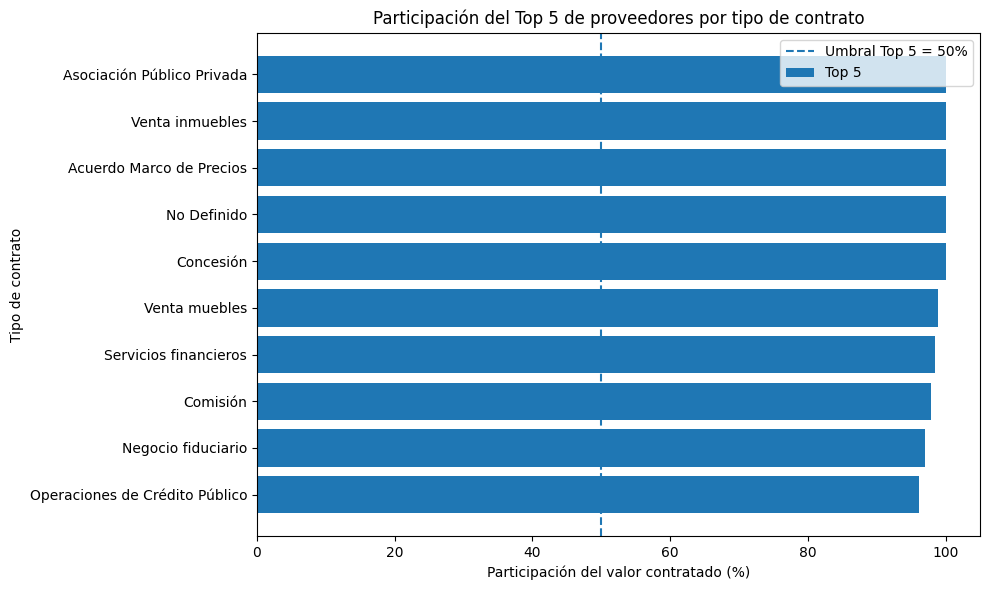

In [35]:
# DEL EQUIPO. Bloque E1: su código aquí (cifra y gráfica del hallazgo).
# [E1] Concentración del valor por tipo de contrato

import matplotlib.pyplot as plt

e1 = tabla_concentracion.copy()

print("E1 — CONCENTRACIÓN DEL VALOR")
print("=" * 70)

print(
    e1[
        [
            COL_NICHO,
            "proveedores_distintos",
            "top5_pct",
            "top10_pct",
            "concentracion_elevada"
        ]
    ].head(10).to_string(index=False)
)

print()
print(
    "Nichos que cumplen el criterio de concentración elevada:",
    int(e1["concentracion_elevada"].sum())
)
print(
    "Total de nichos analizados:",
    len(e1)
)

# Gráfica
grafica_e1 = e1.head(10).sort_values("top5_pct")

plt.figure(figsize=(10, 6))

plt.barh(
    grafica_e1[COL_NICHO].astype(str),
    grafica_e1["top5_pct"],
    label="Top 5"
)

plt.axvline(
    50,
    linestyle="--",
    label="Umbral Top 5 = 50%"
)

plt.xlabel("Participación del valor contratado (%)")
plt.ylabel("Tipo de contrato")
plt.title("Participación del Top 5 de proveedores por tipo de contrato")
plt.legend()
plt.tight_layout()
plt.show()

### [E2] Título del hallazgo 2

E2 — PROVEEDORES DISTINTOS Y CONCENTRACIÓN
              tipo_de_contrato  proveedores_distintos   top5_pct  top10_pct
       Prestación de servicios               237591.0  11.329267  13.983809
                          Otro                 7351.0  20.689412  29.613570
                   Compraventa                 2594.0  47.799134  53.240175
    Arrendamiento de inmuebles                 2199.0  29.418718  36.471695
           Decreto 092 de 2017                 2106.0  33.256133  41.454188
                   Suministros                 1924.0  38.406720  48.382238
                          Obra                 1666.0  13.443766  20.040665
                 Interventoría                  623.0  15.847068  23.873730
                   Consultoría                  481.0  18.995758  27.830930
                      Comodato                  227.0  85.399373  90.560182
         Servicios financieros                   83.0  98.510508  99.332142
      Arrendamiento de muebles               

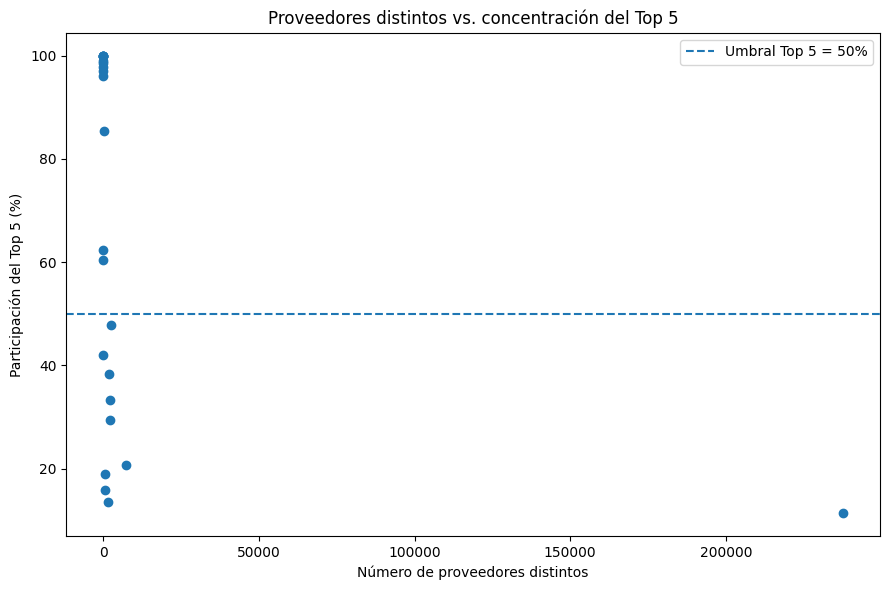

In [37]:
# DEL EQUIPO. Bloque E2: su código aquí.
# [E2] Número de proveedores y concentración del Top 5

e2 = tabla_concentracion.copy()

print("E2 — PROVEEDORES DISTINTOS Y CONCENTRACIÓN")
print("=" * 70)

e2_mostrar = e2.sort_values(
    ["proveedores_distintos", "top5_participacion"],
    ascending=[False, False]
)

print(
    e2_mostrar[
        [
            COL_NICHO,
            "proveedores_distintos",
            "top5_pct",
            "top10_pct"
        ]
    ].to_string(index=False)
)

print()
print("Promedio de proveedores distintos por nicho:",
      f"{e2['proveedores_distintos'].mean():,.1f}")

print("Mediana de proveedores distintos por nicho:",
      f"{e2['proveedores_distintos'].median():,.0f}")

# Relación entre número de proveedores y concentración
plt.figure(figsize=(9, 6))

plt.scatter(
    e2["proveedores_distintos"],
    e2["top5_pct"]
)

plt.axhline(
    50,
    linestyle="--",
    label="Umbral Top 5 = 50%"
)

plt.xlabel("Número de proveedores distintos")
plt.ylabel("Participación del Top 5 (%)")
plt.title("Proveedores distintos vs. concentración del Top 5")
plt.legend()
plt.tight_layout()
plt.show()

### [E3] Título del hallazgo 3

E3 — RECURRENCIA PROVEEDOR–ENTIDAD
Pares proveedor-entidad analizados: 314,421
Pares con más de un contrato: 157,865

documento_proveedor                                                              proveedor_adjudicado nit_entidad                                               nombre_entidad  contratos  valor_total
          899999115                                                                        ETB SA ESP   899999061                            ALCALDIA LOCAL RAFAEL URIBE URIBE         60 3.037225e+11
          860065036                                                            HERRAMIENTAS UNIDAS SA   901526664                     OPERADORA DISTRITAL DE TRANSPORTE S.A.S.         54 2.336325e+08
          860005068 CONGREGACION DE RELIGIOSOS TERCIARIOS CAPUCHINOS DE NUESTRA SEÑORA DE LOS DOLORES   899999239                                           ICBF SEDE NACIONAL         53 6.308276e+10
          860018862                                                                   

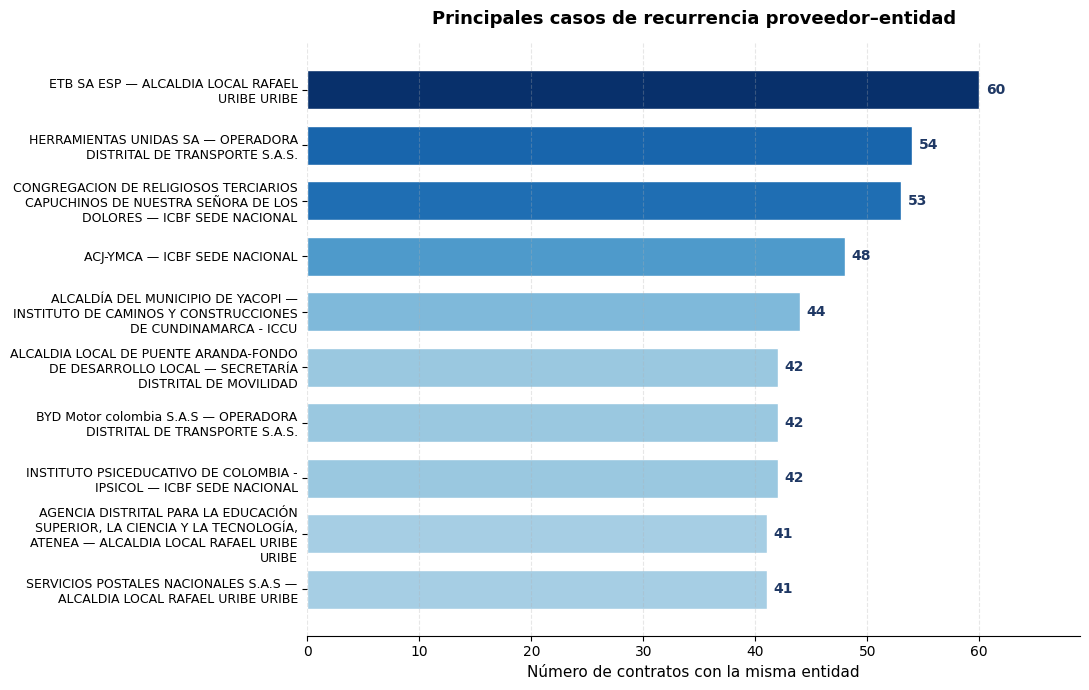

In [42]:
# DEL EQUIPO. Bloque E3: su código aquí.
# [E3] Recurrencia del mismo proveedor con la misma entidad

recurrencia = (
    df_concentracion
    .groupby(
        [COL_PROVEEDOR_ID, COL_ENTIDAD_ID],
        dropna=False
    )
    .agg(
        contratos=(COL_ID_CONTRATO, "nunique"),
        valor_total=(COL_VALOR, "sum")
    )
    .reset_index()
)

# Agregar nombre del proveedor
proveedores = (
    df_concentracion[
        [COL_PROVEEDOR_ID, COL_PROVEEDOR_NOMBRE]
    ]
    .drop_duplicates(COL_PROVEEDOR_ID)
)

recurrencia = recurrencia.merge(
    proveedores,
    on=COL_PROVEEDOR_ID,
    how="left"
)

# Agregar nombre de la entidad
entidades = (
    df_concentracion[
        [COL_ENTIDAD_ID, COL_ENTIDAD_NOMBRE]
    ]
    .drop_duplicates(COL_ENTIDAD_ID)
)

recurrencia = recurrencia.merge(
    entidades,
    on=COL_ENTIDAD_ID,
    how="left"
)

# Casos donde el proveedor tiene más de un contrato con la misma entidad
recurrencia_repetida = recurrencia[
    recurrencia["contratos"] > 1
].copy()

recurrencia_repetida = recurrencia_repetida.sort_values(
    ["contratos", "valor_total"],
    ascending=False
)

print("E3 — RECURRENCIA PROVEEDOR–ENTIDAD")
print("=" * 70)

print(
    "Pares proveedor-entidad analizados:",
    f"{len(recurrencia):,}"
)

print(
    "Pares con más de un contrato:",
    f"{len(recurrencia_repetida):,}"
)

print()

print(
    recurrencia_repetida[
        [
            COL_PROVEEDOR_ID,
            COL_PROVEEDOR_NOMBRE,
            COL_ENTIDAD_ID,
            COL_ENTIDAD_NOMBRE,
            "contratos",
            "valor_total"
        ]
    ].head(15).to_string(index=False)
)
# Gráfica E3 — versión mejorada

import matplotlib.pyplot as plt
import textwrap

top_recurrencia = (
    recurrencia_repetida
    .head(10)
    .sort_values("contratos")
    .copy()
)

# Etiqueta combinada: proveedor + entidad, para que la barra tenga contexto completo
def etiqueta(row, ancho=38):
    texto = f"{row[COL_PROVEEDOR_NOMBRE]} — {row[COL_ENTIDAD_NOMBRE]}"
    return "\n".join(textwrap.wrap(texto, ancho))

top_recurrencia["etiqueta"] = top_recurrencia.apply(etiqueta, axis=1)

fig, ax = plt.subplots(figsize=(11, 7))

# Color en degradé: más contratos = color más intenso
colores = plt.cm.Blues(
    0.35 + 0.65 * (top_recurrencia["contratos"] - top_recurrencia["contratos"].min())
    / (top_recurrencia["contratos"].max() - top_recurrencia["contratos"].min())
)

barras = ax.barh(
    top_recurrencia["etiqueta"],
    top_recurrencia["contratos"],
    color=colores,
    edgecolor="white",
    height=0.7
)

# Anotar el valor exacto al final de cada barra
for barra, contratos in zip(barras, top_recurrencia["contratos"]):
    ax.text(
        barra.get_width() + 0.6,
        barra.get_y() + barra.get_height() / 2,
        f"{int(contratos)}",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
        color="#1F3864"
    )

ax.set_xlabel("Número de contratos con la misma entidad", fontsize=11)
ax.set_title(
    "Principales casos de recurrencia proveedor–entidad",
    fontsize=13, fontweight="bold", pad=14
)
ax.set_xlim(0, top_recurrencia["contratos"].max() * 1.15)

# Quitar bordes innecesarios y agregar grilla suave solo en el eje X
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.tick_params(axis="y", labelsize=9)

plt.tight_layout()
plt.show()

# 6. Tablero de evidencia (para diligenciar por el equipo)
El mismo formato de la plantilla entregada. El tablero se compone de tres tarjetas.

## Tarjeta 1
- **Hallazgo**: En algunos tipos de contrato, una proporción elevada del valor contratado se concentra en los cinco principales proveedores.
- **Cifra**: Top 5 = [X]% del valor en el tipo de contrato [TIPO].
- **Fuente en el notebook E1**: Concentración del valor por tipo de contrato.
- **Hipótesis explicativa**: La concentración observada es compatible con la especialización de determinados proveedores, la existencia de mercados con pocos participantes o la agrupación de contratos de alto valor en proveedores específicos.
Estos datos por sí solos no permiten establecer una relación causal.
- **Duda pendiente**: ¿La concentración se mantiene cuando se comparan grupos más comparables o se incorpora otra variable relevante del proceso de contratación?

## Tarjeta 2
- **Hallazgo**: Los tipos de contrato presentan diferencias importantes en el número de proveedores identificados, por lo que una alta participación del Top 5 debe interpretarse junto con el tamaño del conjunto de proveedores.
- **Cifra**: El nicho [TIPO] registra [X] proveedores distintos y un Top 5 que representa [Y]% del valor.
- **Fuente en el notebook E2**: Proveedores distintos y concentración del Top 5.
- **Hipótesis explicativa**: Una concentración elevada puede coexistir con un número reducido de proveedores debido a características particulares del nicho, como especialización técnica o escala de los contratos.
- **Duda pendiente**: ¿La concentración cambia al controlar o comparar por una característica adicional del proceso, como modalidad de contratación, entidad o sector?

## Tarjeta 3
- **Hallazgo**: Se identifican casos en los que un mismo proveedor, identificado mediante su documento, aparece en múltiples contratos con la misma entidad.
- **Cifra**: Se identificaron [X] pares proveedor–entidad con más de un contrato; el caso con mayor recurrencia presenta [Y] contratos.
- **Fuente en el notebook E3**: Recurrencia proveedor–entidad.
- **Hipótesis explicativa**: La recurrencia puede ser compatible con relaciones contractuales repetidas, necesidades continuas de una entidad o especialización del proveedor. La recurrencia por sí sola no demuestra falta de competencia.
- **Duda pendiente**: ¿La recurrencia observada también aparece al comparar entidades, modalidades o tipos de contrato similares?


In [41]:
# DEL EQUIPO. Resumen automático para el tablero de evidencia

print("=" * 80)
print("TABLERO DE EVIDENCIA — SEMANA 1")
print("=" * 80)

# TARJETA 1
fila_e1 = tabla_concentracion.iloc[0]

print("\n🟦 TARJETA 1 — CONCENTRACIÓN")
print("-" * 80)

print(
    f"Tipo de contrato: {fila_e1[COL_NICHO]}"
)

print(
    f"Top 5: {fila_e1['top5_pct']:.2f}% del valor"
)

print(
    f"Top 10: {fila_e1['top10_pct']:.2f}% del valor"
)

print(
    f"Proveedores distintos: {int(fila_e1['proveedores_distintos']):,}"
)

print(
    f"¿Cumple criterio de concentración?: "
    f"{'Sí' if fila_e1['concentracion_elevada'] else 'No'}"
)


# TARJETA 2
fila_mas_proveedores = tabla_concentracion.loc[
    tabla_concentracion["proveedores_distintos"].idxmax()
]

print("\n🟦 TARJETA 2 — DIVERSIDAD DE PROVEEDORES")
print("-" * 80)

print(
    f"Tipo de contrato con más proveedores: "
    f"{fila_mas_proveedores[COL_NICHO]}"
)

print(
    f"Proveedores distintos: "
    f"{int(fila_mas_proveedores['proveedores_distintos']):,}"
)

print(
    f"Participación Top 5: "
    f"{fila_mas_proveedores['top5_pct']:.2f}%"
)

print(
    f"Participación Top 10: "
    f"{fila_mas_proveedores['top10_pct']:.2f}%"
)


# TARJETA 3
print("\n🟦 TARJETA 3 — RECURRENCIA")
print("-" * 80)

print(
    f"Pares proveedor-entidad analizados: "
    f"{len(recurrencia):,}"
)

print(
    f"Pares con más de un contrato: "
    f"{len(recurrencia_repetida):,}"
)

if len(recurrencia_repetida) > 0:

    mayor_recurrencia = recurrencia_repetida.iloc[0]

    print(
        f"Mayor número de contratos del mismo proveedor "
        f"con una entidad: {int(mayor_recurrencia['contratos'])}"
    )

    print(
        f"Proveedor: {mayor_recurrencia[COL_PROVEEDOR_NOMBRE]}"
    )

    print(
        f"Entidad: {mayor_recurrencia[COL_ENTIDAD_NOMBRE]}"
    )

TABLERO DE EVIDENCIA — SEMANA 1

🟦 TARJETA 1 — CONCENTRACIÓN
--------------------------------------------------------------------------------
Tipo de contrato: Acuerdo Marco de Precios
Top 5: 100.00% del valor
Top 10: 100.00% del valor
Proveedores distintos: 5
¿Cumple criterio de concentración?: Sí

🟦 TARJETA 2 — DIVERSIDAD DE PROVEEDORES
--------------------------------------------------------------------------------
Tipo de contrato con más proveedores: Prestación de servicios
Proveedores distintos: 237,591
Participación Top 5: 11.33%
Participación Top 10: 13.98%

🟦 TARJETA 3 — RECURRENCIA
--------------------------------------------------------------------------------
Pares proveedor-entidad analizados: 314,421
Pares con más de un contrato: 157,865
Mayor número de contratos del mismo proveedor con una entidad: 60
Proveedor: ETB SA ESP
Entidad: ALCALDIA LOCAL RAFAEL URIBE URIBE


# 7. Semana 2. ¿Su conclusión sobrevive?
No usar antes de recibir la objeción. La objeción de su expediente señala una variable concreta; esta sección trae las herramientas para incorporarla: comparar grupos comparables y verificar si el hallazgo de la semana 1 se mantiene, se debilita o desaparece.


In [ ]:
# SEMANA 2. PREPARADA. comparación de grupos (plantilla)
# Compara la variable clave entre dos grupos definidos por una columna categórica.

def comparar_grupos(df, col_grupo, col_valor, grupo_a, grupo_b):
    """Mediana, P25-P75 y n de la variable en dos grupos, lado a lado."""
    piezas = {}
    for g in (grupo_a, grupo_b):
        s = df.loc[df[col_grupo] == g, col_valor].dropna()
        piezas[g] = {
            "n": f"{s.size:,}",
            "mediana": f"${s.median():,.0f}" if s.size else "—",
            "P25": f"${s.quantile(.25):,.0f}" if s.size else "—",
            "P75": f"${s.quantile(.75):,.0f}" if s.size else "—",
        }
    return pd.DataFrame(piezas)

# Ejemplo (ajusten grupo y valor a su objeción):
# comparar_grupos(df, COL["modalidad"], COL["valor"], "Contratación directa", "Licitación pública")

## 7.1. Potencia: cuántos datos se necesitan para detectar una diferencia
La calculadora de potencia responde la siguiente pregunta: si la diferencia real entre dos grupos es de cierto tamaño, cuántas observaciones por grupo se necesitan para detectarla con confianza. El soporte conceptual está en la cápsula de la semana 2.


In [ ]:
# SEMANA 2. PREPARADA. Calculadora de potencia.
from statsmodels.stats.power import TTestIndPower


def n_por_grupo(tamano_efecto, alfa=0.05, potencia=0.8):
    """Observaciones por grupo para detectar un efecto (d de Cohen) dado.
    Referencia intuitiva: d=0.2 efecto pequeño, d=0.5 mediano, d=0.8 grande."""
    n = TTestIndPower().solve_power(effect_size=tamano_efecto, alpha=alfa, power=potencia)
    return int(round(n))


for d in (0.1, 0.2, 0.5, 0.8):
    print(f"efecto d={d:<4}: ~{n_por_grupo(d):>5,} contratos por grupo")

# Lectura del ejemplo: una diferencia sutil (d=0.1) entre dos entidades exige ~1.571
# contratos por grupo; una diferencia grande (d=0.8) se detecta con ~26 por grupo.
# Si la comparacion tiene grupos pequeños, la ausencia de diferencia detectable
# puede deberse a falta de potencia; documentarlo como limitacion cuando aplique.

efecto d=0.1 : ~1,571 contratos por grupo
efecto d=0.2 : ~  393 contratos por grupo
efecto d=0.5 : ~   64 contratos por grupo
efecto d=0.8 : ~   26 contratos por grupo


## 7.2. Evidencia causal más fuerte (para diligenciar por el equipo)
Estos cuatro campos alimentan la tarjeta de veredicto.

1. Experimento ideal (si fuera ética, legal y operativamente posible, qué se asignaría al azar): …
2. Variable de resultado (qué se mediría): …
3. Alternativa factible (si no se puede experimentar, qué comparación observacional sería razonable): …
4. Potencia (tamaño de efecto de interés y n aproximado por grupo, según la calculadora de 7.1): …


# 8. Declaración de uso de herramientas de IA (obligatoria)

- Herramienta empleada: …
- Actividad en la que se empleó: …
- Resultado que fue verificado y forma de verificación: …
- Decisión del equipo que no se delegó a la herramienta: …


# 9. Cierre
Al terminar la semana 1, este notebook regenera su tablero completo de principio a fin; al terminar la semana 2, también su respuesta a la objeción y su veredicto. Si Restart and Run All produce todas sus cifras sin intervención manual, el trabajo está donde debe estar.
